# Impact of model resolution and comparison to observations

## Background

### Motivation

Because we have started to work with gridded data, we should think a bit about the role of spatial resolution, in what we are seeing. 

This is particularly important, when we want to compare local data to data from models. We need to make sure that we have an _apples-to-apples_ comparison: 

- **Station data**: Provides observations at a specific location (right there!). The question is how representative this is compared to a larger area. 
- **Traditional climate models**: Climate models are very computationally expensive. 
    This means they were typically run at resolutions of  $1^\circ \times 1^\circ$ or $2^\circ \times 2^\circ$. They lack sufficient detail to resolve topography, like the Blue Ridge Mountains, and local climate patterns. For example, current operational climate models, like the [CMIP-6 (Coupled Model Intercomparison Project - Phase 6)](https://wcrp-cmip.org/cmip6/) models operate at a resolution of $1.25^\circ \, \text{latitude} \times 2.5^\circ \, \text{longitude}$, which corresponds roughly to spatial grid resolutions of 100 to 250 km .  
- **Current climate models**: Using today's computational power, it is possible to run climate models at resolutions of 30-50 km over climate relevant timescales (i.e. the end of the century). 
- **Weather forecast models**: Today's global weather forecasts are run at resolutions of about $16 \times 16 km^2$. 
- **[Experimental climate models](https://eos.org/features/are-we-entering-the-golden-age-of-climate-modeling)**: Are currently run at spatial resolutions of 3-5 km, but this cannot yet be done globally for long periods. 

**Today's exercise is aimed at directly visualizing the difference in detail in such simulations using rainfall in Virginia as an example.**

### Dataset

For this, we will be working with [PRISM High-Resolution Climate Data](https://www.nacse.org/prism/). 

**Note that this is not climate model data, but data from observations. This allows us to look at data with higher-resolution than available in typical climate model simulations.** 

> PRISM is a set of monthly, yearly, and single-event gridded data products of mean temperature and precipitation, max/min temperatures, and dewpoints, primarily for the United States. In-situ point measurements are ingested into the PRISM (Parameter elevation Regression on Independent Slopes Model) statistical mapping system. The PRISM products use a weighted regression scheme to account for complex climate regimes associated with orography, rain shadows, temperature inversions, slope aspect, coastal proximity, and other factors. [UCAR Climate Data Guide](https://climatedataguide.ucar.edu/climate-data/prism-high-resolution-spatial-climate-data-united-states-maxmin-temp-dewpoint)

The dataset is available at 800 m resolution throughout the contiguous US, but requires a license. Here, we use the free version with a resolution of 4 km.

![](../assets/PRISM_ppt_early_4kmD2_MTD_20240415_small.png)

_Figure 1: Example of PRISM precipitation data for April, 2024 with 4 km resolution. Credit:[PRISM Climate Group](https://prism.oregonstate.edu/mtd/)_

#### Data Preparation

For this exercise, I downloaded the average annual precipitation at 4 km dataset available from the [PRISM website](https://prism.oregonstate.edu/normals/). I then processed the data, which was available in binary format to netCDF file format.

## Learning Goals

**Technical**

This exercise practices several skills that we have previously encountered:

- Opening and reading datasets using _xarray_
- Selecting and subsetting variables from an _xarray_- dataset.
- Plotting _xarray_ data on maps. 

New:

- Use the `.coarsen()` aggregation function to downsample data. 

**Climate System**

After completing this exercise you should be able to

- recognize the importance of high resolution climate data for local and regional climate adaptation
- compare and contrast precipitation patterns near Harrisonburg at different resolutions
- be able to relate this to questions surrounding gridded data in general and for your semester project

In [1]:
# Import the tools we are going to need today:
import matplotlib.pyplot as plt  # plotting library
import numpy as np  # numerical library
import xarray as xr  # netCDF library
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list
import glob

## Data Analysis

### Reading the data to _xarray

First, and as always we have to read in the data as an _xarray_ dataset. 

The data file is named `PRISM_ppt_30yr_normal_4kmM4_annual.nc` and located in the `Data` directory. 


In [2]:
pathToFile = '../Data/PRISM_ppt_30yr_normal_4kmM4_annual.nc'
ds_4km = xr.open_dataset(pathToFile)

Let's inspect the dataset to see what we have.  

In [3]:
ds_4km

<xarray.Dataset> Size: 3MB
Dimensions:  (lat: 621, lon: 1405)
Coordinates:
  * lat      (lat) float32 2kB 49.94 49.9 49.85 49.81 ... 24.23 24.19 24.15 24.1
  * lon      (lon) float32 6kB -125.0 -125.0 -124.9 ... -66.6 -66.56 -66.52
Data variables:
    precip   (lat, lon) float32 3MB ...

Based on the information abovem you can see that it is a 2D dataset with `lat` and `lon` coordinates (i.e. something we can plot on a map). There is a single variable in the dataset called `precip`, which corresponds to precipitation in mm/year. 

### Dataset processing

To help us visualize the impact of resolution, let's ***decrease (or coarsen)*** the spatial resolution. _xarray_ has the built-in [`.coarsen()`method](https://docs.xarray.dev/en/latest/generated/xarray.Dataset.coarsen.html).  

What we do below is to 

1. first average the data over 4 grid points in the latitude direction and then
2. to do the same in the longitude direction.
3. Finally, we save a copy of that data into a new _xarray_ dataset.
   
This means, instead of the initial spatial resolution of 4 km x 4 km, we now have a resolution of 16 km x 16 km, which is similar to a weather forecasting model. 

In [4]:
ds_16km = ds_4km.coarsen(lat=4, boundary='trim').mean().coarsen(lon=4, boundary='trim').mean()

Try doing the same thing to coarsen the resolution to 200 km x 200 km (i.e. the resolution of a traditional climate model as they were run just a few years ago). 

In [5]:
ds_40km = ds_4km.coarsen(lat=10, boundary='trim').mean().coarsen(lon=10, boundary='trim').mean()
ds_200km = ds_4km.coarsen(lat=50, boundary='trim').mean().coarsen(lon=50, boundary='trim').mean()

### Data Visualization 

Now let's see how different they look. 

I first set up some basic figure properties, you don't have to change this.  

C:\Users\tobia\anaconda3\envs\ISAT_420\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


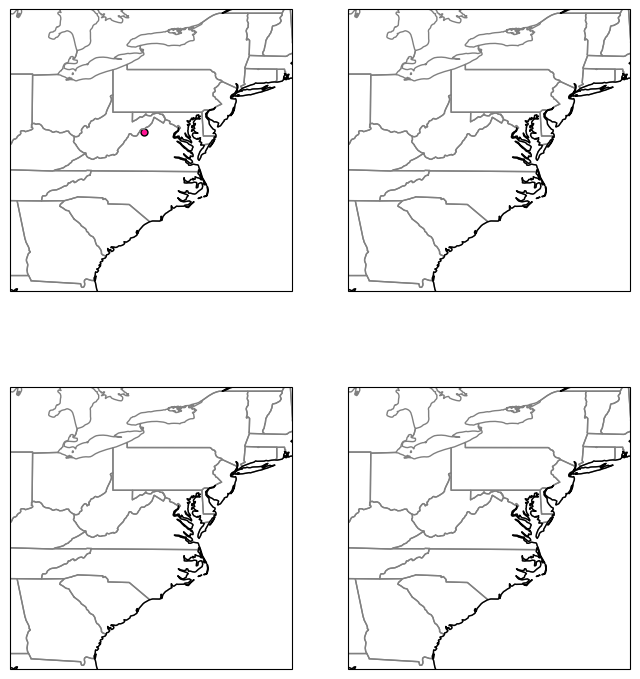

In [6]:
hBurgLat = 38.44957 # Latitude of Harrisonburg for visualization
hBurgLon = -78.86892 # Longitude of Harrisonburg for visualization

midAtlanticBox = [-86, 30, -71, 45] # coordinates to set the extent of the map

# I am setting up a figure object with 2x2 subplots and a map projection
fig, ax = plt.subplots(nrows = 2, ncols=2, figsize=(8,9), subplot_kw=dict(projection=ccrs.PlateCarree()))

# ax refers to the subplot object and goes from. It is an array of size 2x2. 
# Here I am looping over all subplots to add the statelines and to set the boundary of the plotted map.
for i in range(2):
    for j in range(2):
        ax[i,j].set_extent([midAtlanticBox[0], midAtlanticBox[2], midAtlanticBox[1], midAtlanticBox[3]], ccrs.PlateCarree())
        ax[i,j].add_feature(cartopy.feature.STATES,edgecolor='grey')
        ax[i,j].coastlines(linewidth=1)

# I can also go to a specific subplot.
# For example to add a point at the center of the to the top left subplot, I could do.
ax[0,0].scatter(hBurgLon, hBurgLat, c='deeppink', s=25, edgecolors='k', linewidth=1, transform=ccrs.PlateCarree())


Now let's redo this, and plot the 4 km data onto the generated map.

We also add a marker for Harrisonburg, a nice figure title, and a colorbar legend. 


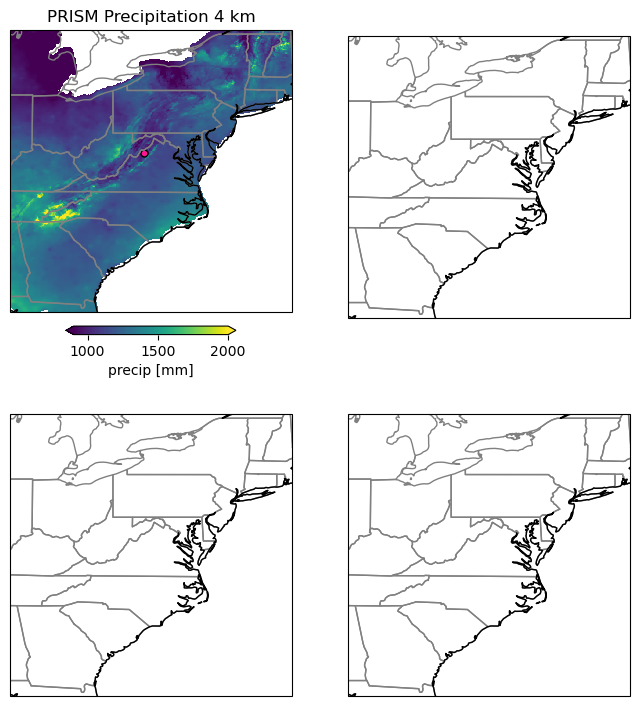

In [7]:
# I am setting up a figure object with 2x2 subplots and a map projection
fig, ax = plt.subplots(nrows = 2, ncols=2, figsize=(8,9), subplot_kw=dict(projection=ccrs.PlateCarree()))

# ax refers to the subplot object and goes from. It is an array of size 2x2. 
# Here I am looping over all subplots to add the state lines and to set the boundary of the plotted map.
for i in range(2):
    for j in range(2):
        ax[i,j].set_extent([midAtlanticBox[0], midAtlanticBox[2], midAtlanticBox[1], midAtlanticBox[3]], ccrs.PlateCarree())
        ax[i,j].add_feature(cartopy.feature.STATES,edgecolor='grey')
        ax[i,j].coastlines(linewidth=1)

data = ds_4km.precip.sel(lat=slice(midAtlanticBox[3], midAtlanticBox[1]),lon=slice(midAtlanticBox[0], midAtlanticBox[2]))
data.plot(ax=ax[0,0], 
          transform=ccrs.PlateCarree(), # we always need this for the map projection
          vmin = 900, vmax = 2000, # this sets the range for the colors
          cbar_kwargs={"orientation": "horizontal", "fraction": 0.027, "pad": 0.045} # this defines the location and size of the colorbar
        )

ax[0,0].set_title('PRISM Precipitation 4 km')
ax[0,0].scatter(hBurgLon, hBurgLat, c='deeppink', s=25, edgecolors='k', linewidth=1, transform=ccrs.PlateCarree())

**Now it is your turn:**

- Use the code above as a basis to add the 16 km, 40 km and 200 km datasets.
- Add a title to each subplot.
- Make sure to add the marker for Harrisonburg as well



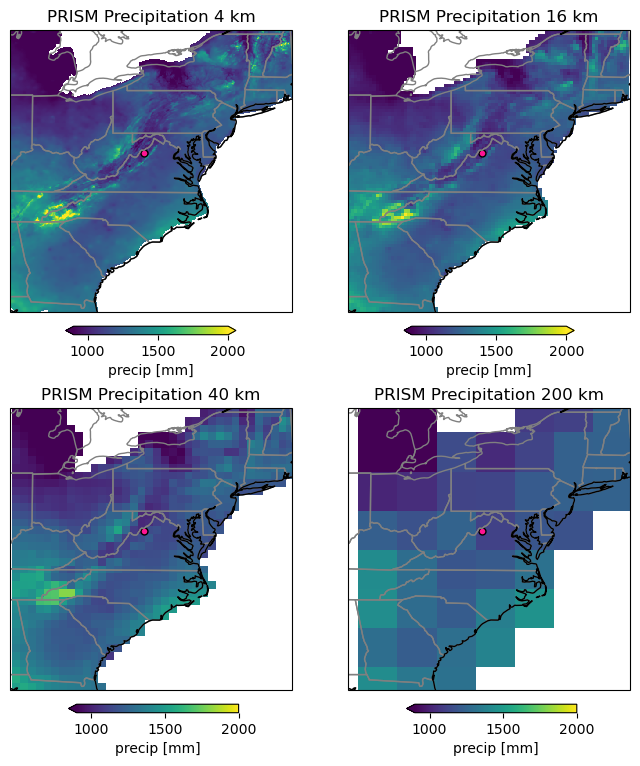

In [8]:
# I am setting up a figure object with 3 subplots and a map projection
fig, ax = plt.subplots(nrows = 2, ncols=2, figsize=(8,9), subplot_kw=dict(projection=ccrs.PlateCarree()))

# ax refers to the subplot object and goes from. It is an array of size 2x2. 
# Here I am looping over all subplots to add the state lines and to set the boundary of the plotted map.
for i in range(2):
    for j in range(2):
        ax[i,j].set_extent([midAtlanticBox[0], midAtlanticBox[2], midAtlanticBox[1], midAtlanticBox[3]], ccrs.PlateCarree())
        ax[i,j].add_feature(cartopy.feature.STATES,edgecolor='grey')
        ax[i,j].coastlines(linewidth=1)

data = ds_4km.precip.sel(lat=slice(midAtlanticBox[3], midAtlanticBox[1]),lon=slice(midAtlanticBox[0], midAtlanticBox[2]))
data.plot(ax=ax[0,0], 
          transform=ccrs.PlateCarree(), # we always need this for the map projection
          vmin = 900, vmax = 2000, # this sets the range for the colors
          cbar_kwargs={"orientation": "horizontal", "fraction": 0.027, "pad": 0.045} # this defines the location and size of the colorbar
        )

ax[0,0].set_title('PRISM Precipitation 4 km')
ax[0,0].scatter(hBurgLon, hBurgLat, c='deeppink', s=25, edgecolors='k', linewidth=1, transform=ccrs.PlateCarree())

## add your code here 
data = ds_16km.precip.sel(lat=slice(midAtlanticBox[3], midAtlanticBox[1]),lon=slice(midAtlanticBox[0], midAtlanticBox[2]))
data.plot(ax=ax[0,1], 
          transform=ccrs.PlateCarree(), # we always need this for the map projection
          vmin = 900, vmax = 2000, # this sets the range for the colors
          cbar_kwargs={"orientation": "horizontal", "fraction": 0.027, "pad": 0.045} # this defines the location and size of the colorbar
        )

ax[0,1].set_title('PRISM Precipitation 16 km')
ax[0,1].scatter(hBurgLon, hBurgLat, c='deeppink', s=25, edgecolors='k', linewidth=1, transform=ccrs.PlateCarree())

data = ds_40km.precip.sel(lat=slice(midAtlanticBox[3], midAtlanticBox[1]),lon=slice(midAtlanticBox[0], midAtlanticBox[2]))
data.plot(ax=ax[1,0], 
          transform=ccrs.PlateCarree(), # we always need this for the map projection
          vmin = 900, vmax = 2000, # this sets the range for the colors
          cbar_kwargs={"orientation": "horizontal", "fraction": 0.027, "pad": 0.045} # this defines the location and size of the colorbar
        )

ax[1,0].set_title('PRISM Precipitation 40 km')
ax[1,0].scatter(hBurgLon, hBurgLat, c='deeppink', s=25, edgecolors='k', linewidth=1, transform=ccrs.PlateCarree())

data = ds_200km.precip.sel(lat=slice(midAtlanticBox[3], midAtlanticBox[1]),lon=slice(midAtlanticBox[0], midAtlanticBox[2]))
data.plot(ax=ax[1,1], 
          transform=ccrs.PlateCarree(), # we always need this for the map projection
          vmin = 900, vmax = 2000, # this sets the range for the colors
          cbar_kwargs={"orientation": "horizontal", "fraction": 0.027, "pad": 0.045} # this defines the location and size of the colorbar
        )

ax[1,1].set_title('PRISM Precipitation 200 km')
ax[1,1].scatter(hBurgLon, hBurgLat, c='deeppink', s=25, edgecolors='k', linewidth=1, transform=ccrs.PlateCarree())



### Discussion:

- Compare the maps
- What do you notice/ find striking
- How much detail do you still see and what does this mean for climate model data to make regional/local decisions
- How could this affect your work, when working with gridded data for the semester project. 

## Coding Challenge

The above code (very likely) has a lot of repetition. This is not good coding practice, because it makes it much harder to implement changes. 

- Discuss how you could remove some of these repetitions. 
- Try to implement these changes. 
    - Hint: loops, if-else statements, dictionaries, and functions in python can be helpful for doing so. 
